In [3]:
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from lsstypes.utils import get_hartlap2007_factor
from clustering_statistics import tools, box_tools


def cov_metrics(cov1, cov2):
    """
    Eqs. (2.17) and (2.18) of arXiv:2404.03007.

    Parameters
    ----------
    cov1 : (N, N) array
        Reference covariance C_R (the matrix to invert).
    cov2 : (N, N) array
        Test covariance C_S.
    assume_a : str, optional
        Passed to scipy.linalg.solve.

    Returns
    -------
    rinv : float
        Eq. (2.17):
            sqrt(tr[(C_R^{-1} C_S - I)^2] / N)
    chi2red : float
        Eq. (2.18):
            tr(C_R^{-1} C_S) / N
    """
    n = cov1.shape[0]
    mat = np.linalg.solve(cov1, cov2)  # C_R^{-1} C_S
    delta = mat - np.eye(n)
    rinv = np.sqrt(np.trace(delta @ delta) / n)
    chi2red = np.trace(mat) / n
    rinv, chi2red = float(np.real_if_close(rinv)), float(np.real_if_close(chi2red))
    print(f"Eq. (2.17): R_inv   = {rinv:.3f}")
    print(f"Eq. (2.18): chi2/N = {chi2red:.3f}")

Using 907 mocks


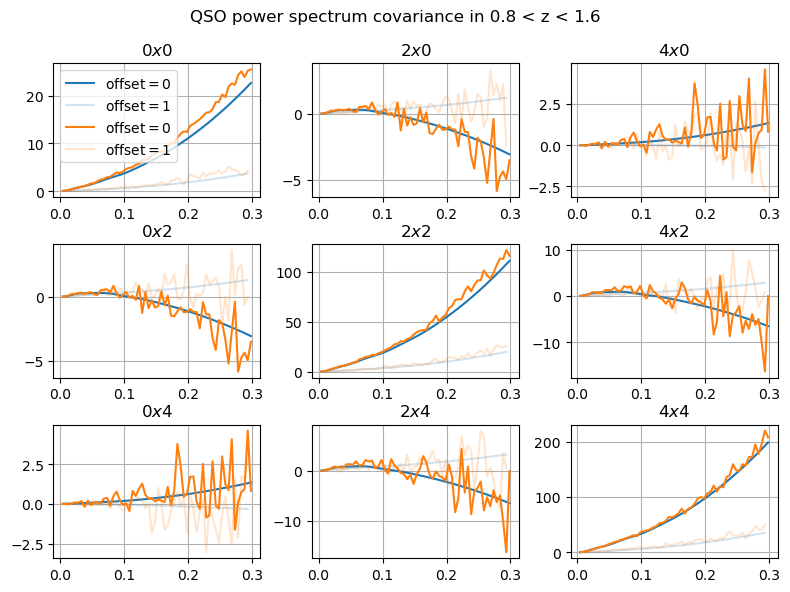

Eq. (2.17): R_inv   = 0.436
Eq. (2.18): chi2/N = 1.104


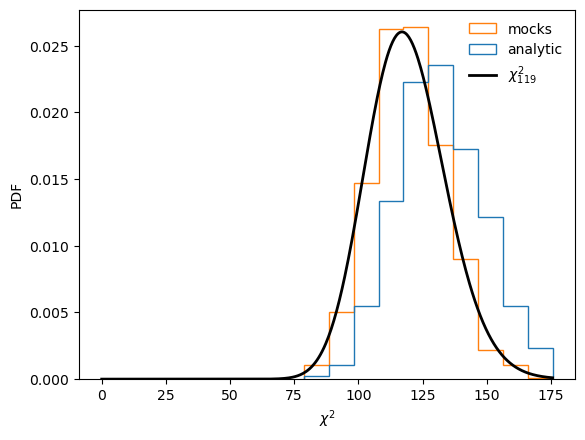

Using 907 mocks


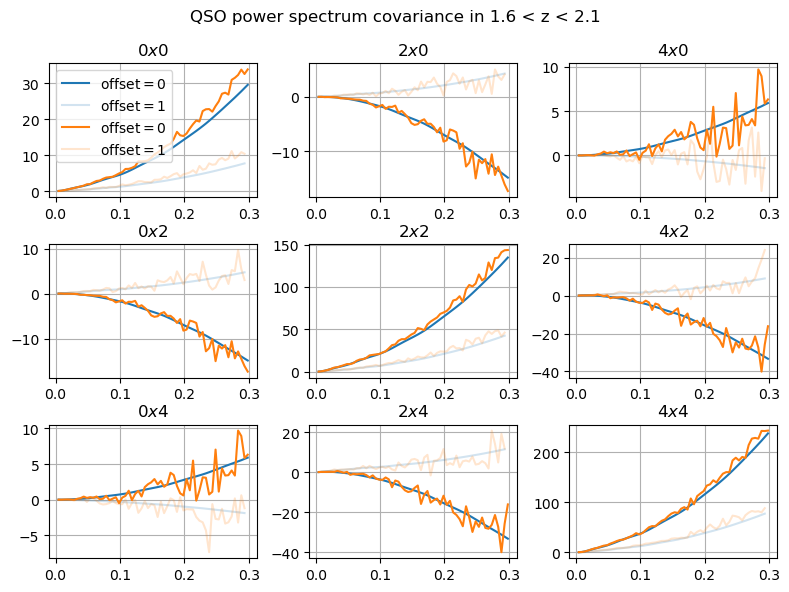

Eq. (2.17): R_inv   = 0.421
Eq. (2.18): chi2/N = 1.079


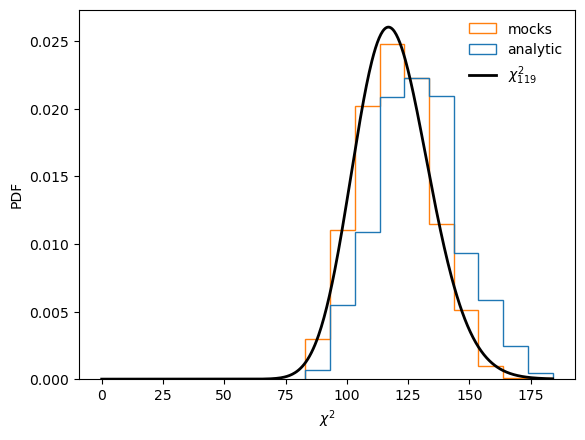

In [11]:
from scipy.stats import chi2

region = 'GCcomb'
version = 'glam-uchuu-v2-altmtl'
tracers = [('QSO', (0.8, 2.1)), ('QSO', (0.8, 1.6)), ('QSO', (1.6, 2.1))][1:]
stats_dir = tools.base_stats_dir
all_mocks = {}

def top_n_outliers_mad(x, n):
    x = np.asarray(x)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    score = np.abs(x - med) / (mad + 1e-12)
    idx = np.argsort(score)[-n:]
    return idx

for tracer, zrange in tracers:
    fn = tools.get_stats_fn(kind='covariance_mesh2_spectrum_poles', stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics',
                            catalog=dict(tracer=tracer, zrange=zrange, version='data-dr2-v2', weight='default-FKP', region=region))
    covariance_analytic = types.read(fn).at.observable.get(observables='spectrum2', tracers=(tools.get_simple_tracer(tracer),) * 2)
    kw_catalog = dict(imock=0, tracer=tracer, zrange=zrange, version=version, weight='default-FKP', region=region)
    fns = [tools.get_stats_fn(kind='mesh2_spectrum_poles', stats_dir=stats_dir, project='full_shape/base', catalog=kw_catalog | {'imock': imock}) for imock in range(2000)]
    fns = [fn for fn in fns if fn.exists()]
    print(f'Using {len(fns):d} mocks')
    mocks = [types.read(fn) for fn in fns]
    if False:
        sns = [mock.get(ells=0).values('shotnoise').mean() for mock in mocks]
        print(f'Shotnoise is {np.mean(sns):.0f}+-{np.std(sns):.0f}')
    
        def select_outliers(mocks, n=1):
            p0 = [mock.get(ells=0).select(k=(0.1, 0.4)).value().mean() for mock in mocks]
            return top_n_outliers_mad(p0, n)
        
        idx = select_outliers(mocks, n=len(mocks) // 20)
        mocks = list(mocks)
        all_mocks[tracer] = {imock: mock for imock, mock in enumerate(mocks) if imock not in idx}
        mocks = list(all_mocks[tracer].values())
    if False:
        fig, ax = plt.subplots()
        for ill, ell in enumerate(mocks[0].ells):
            color = f'C{ill:d}'
            for mock in mocks:
                pole = mock.get(ells=ell)
                ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, alpha=0.2)
        ax.set_ylabel(rf'$k P_\ell(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
        ax.set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
        plt.show()
        plt.close(fig)

    covariance_mocks = types.cov(mocks)
    observable = covariance_analytic.observable.select(k=slice(0, None, 5)).select(k=(0., 0.3))
    covariance_analytic = covariance_analytic.at.observable.match(observable)
    covariance_mocks = covariance_mocks.at.observable.match(observable)
    kw = dict(ytransform=lambda x, y: x**4 * y, offset=np.arange(2))
    fig = covariance_analytic.plot_diag(**kw, show=False, color='C0')
    fig.suptitle(f'{tracer} power spectrum covariance in {zrange[0]:.1f} < z < {zrange[1]:.1f}', fontsize=12)
    covariance_mocks.plot_diag(**kw, fig=fig, color='C1', show=True)

    observable = covariance_analytic.observable.get(ells=[0, 2])
    all_data = [mock.match(observable).value() for mock in mocks]
    
    cov_metrics(covariance_analytic.at.observable.match(observable).value(),
                covariance_mocks.at.observable.match(observable).value())
    covariance_inverse_analytic = covariance_analytic.at.observable.match(observable).inv()
    covariance_inverse_mocks = covariance_mocks.at.observable.match(observable).inv()
    mean = np.mean(all_data, axis=0)
    factor = get_hartlap2007_factor(nobs=len(all_data), nbins=mean.size)
    all_chi2_analytic = [(data - mean).dot(covariance_inverse_analytic).dot(data - mean) for data in all_data]
    all_chi2_mocks = [(data - mean).dot(covariance_inverse_mocks).dot(data - mean) for data in all_data]
    fig, ax = plt.subplots()
    ndof = mean.size - 1
    x = np.linspace(0, max(all_chi2_mocks), 500)
    _, bins, _ = ax.hist(all_chi2_mocks, histtype='step', color='C1', density=True, label='mocks')
    ax.hist(all_chi2_analytic, histtype='step', color='C0', density=True, bins=bins, label='analytic')
    ax.plot(x, chi2.pdf(x, ndof), 'k-', lw=2, label=rf'$\chi^2_{{{ndof}}}$')
    ax.set_xlabel(r'$\chi^2$')
    ax.set_ylabel('PDF')
    ax.legend(frameon=False)
    plt.show()
    